In [1]:
import random
import time
import copy

import numpy as np
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter
from shutil import copyfile, rmtree
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
# For getting output of intermediate layers in Pytorch
from torch_intermediate_layer_getter import IntermediateLayerGetter as LayerGetter
# For interactive visualization
from torch.utils.tensorboard import SummaryWriter

import torchvision
from torchvision import transforms 

from pathlib import Path

%load_ext tensorboard

In [2]:
def set_seed(seed=None, seed_torch=True):
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')

# In case that `DataLoader` is used
def seed_worker(worker_id):
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

def set_device():
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

In [3]:
SEED = 42
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 42 has been set.
GPU is enabled in this notebook.


In [4]:
pre_training_target = "clear"
target = "blur_5"

batch_size = 2048 # 2048 as the max batch size for 32GB V100 GPU 

lr_type = "Default"

training_lr = 1e-3 
pre_training_lr = 3e-4 

training_num_epoch = 40 
pre_training_num_epoch = 40 

lamda_2 = 0.01

patience = 5

optim_type = "AdamW"

In [5]:
# import os, zipfile, requests

# filenames = ["catvdog_clear.zip",
#              "catvdog_blur_2.zip",
#              "catvdog_blur_5.zip"]

# urls = ["https://osf.io/hj2gd/download",
#         "https://osf.io/xp6qd/download",
#         "https://osf.io/wj43a/download"]
# for fname, url in zip(filenames, urls):
#   if not os.path.isfile(fname):
#     try:
#       r = requests.get(url)
#     except requests.ConnectionError:
#       print("!!! Failed to download data !!!")
#     else:
#       if r.status_code != requests.codes.ok:
#         print("!!! Failed to download data !!!")
#       else:
#         with open(fname, "wb") as fid:
#           fid.write(r.content)

# for fname in filenames:
#   zip_ref = zipfile.ZipFile(fname, 'r')
#   zip_ref.extractall()
#   zip_ref.close()
  # os.remove(fname)

In [6]:
# Define Preprocessing Filters
preprocessing = transforms.Compose([transforms.ToTensor(),
                                    transforms.Resize((256, 256)),
                                    transforms.Normalize((0.5, 0.5, 0.5),
                                                         (0.5, 0.5, 0.5))]) # tunable variables, can play around with that

# Create Clean Training Dataset using ImageFolder
clear_train_data = torchvision.datasets.ImageFolder(
    root="dataset/train",
    transform=preprocessing
)

# Create Clean Test Dataset using ImageFolder
clear_test_data = torchvision.datasets.ImageFolder(
    root="dataset/test",
    transform=preprocessing
)

# Create Noisy Training Dataset using ImageFolder
noisy_train_data = torchvision.datasets.ImageFolder(
    root="dataset_" + target + "/train",
    transform=preprocessing
)

# Create Noisy Test Dataset using ImageFolder
noisy_test_data = torchvision.datasets.ImageFolder(
    root="dataset_" + target + "/test",
    transform=preprocessing
)

# function to apply a training-validation set split on a dataset
def validation_split(train_data, val_ratio = 0.2):
  train_indices, val_indices, _, _ = train_test_split(range(len(train_data)),
                                                      train_data.targets,
                                                      stratify=train_data.targets,
                                                      test_size=val_ratio)
  train_split = torch.utils.data.Subset(train_data, train_indices)
  val_split = torch.utils.data.Subset(train_data, val_indices)
  return train_split,val_split

# Define Batch Size
# batch_size = 8192

# Define Dataloaders for Training, Validation and Test sets
clear_train_split,clear_val_split = validation_split(clear_train_data)
clear_train_batches = torch.utils.data.DataLoader(clear_train_split,
                                                  batch_size=batch_size,
                                                  shuffle=True)
clear_val_batches = torch.utils.data.DataLoader(clear_val_split,
                                                batch_size=batch_size,
                                                shuffle=True)
clear_test_batches = torch.utils.data.DataLoader(clear_test_data,
                                                 batch_size=batch_size,
                                                 shuffle=True)

noisy_train_split,noisy_val_split = validation_split(noisy_train_data)
noisy_train_batches = torch.utils.data.DataLoader(noisy_train_split,
                                                  batch_size=batch_size,
                                                  shuffle=True)
noisy_val_batches = torch.utils.data.DataLoader(noisy_val_split,
                                                batch_size=batch_size,
                                                shuffle=True)
noisy_test_batches = torch.utils.data.DataLoader(noisy_test_data,
                                                 batch_size=batch_size,
                                                 shuffle=True)

In [7]:
print(clear_train_data)
# Get an example of a clear and noisy versions of cat and dog image
# clear_cat_image = clear_train_data[5][0].unsqueeze(0)
clear_dog_image = clear_train_data[19997][0].unsqueeze(0)
noisy_cat_image = noisy_train_data[5][0].unsqueeze(0)
noisy_dog_image = noisy_train_data[19997][0].unsqueeze(0)

clear_cat_image = clear_train_data[5][0]
# clear_dog_image = clear_train_data[19997][0]
# noisy_cat_image = noisy_train_data[5][0]
# noisy_dog_image = noisy_train_data[19997][0]

print(clear_cat_image.shape)

Dataset ImageFolder
    Number of datapoints: 22442
    Root location: dataset/train
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )
torch.Size([3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9781502..0.99762356].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43051553..1.0000005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271478..0.97307384].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3793819..1.0000005].


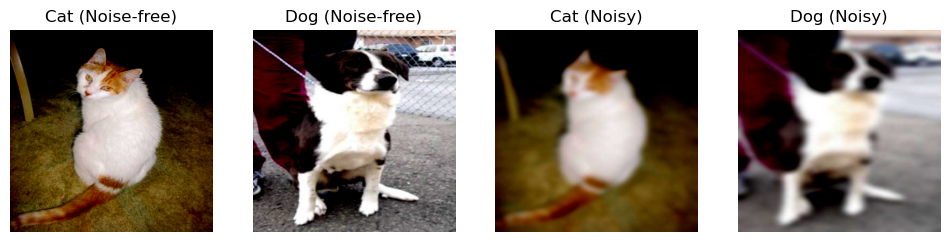

In [8]:
fig = plt.figure(figsize=(12, 3))
ax=fig.add_subplot(141)
ax.imshow(clear_cat_image.permute(1, 2, 0))
plt.axis('off')
plt.title('Cat (Noise-free)')
ax=fig.add_subplot(142)
ax.imshow(clear_dog_image.squeeze(0).permute(1, 2, 0))
plt.axis('off')
plt.title('Dog (Noise-free)')
ax=fig.add_subplot(143)
ax.imshow(noisy_cat_image.squeeze(0).permute(1, 2, 0))
plt.axis('off')
plt.title('Cat (Noisy)')
ax=fig.add_subplot(144)
ax.imshow(noisy_dog_image.squeeze(0).permute(1, 2, 0))
plt.axis('off')
plt.title('Dog (Noisy)')
plt.show()

In [9]:
# Define AlexNet with different modules representing different brain areas
class AlexNet(nn.Module):

  def __init__(self, num_classes=1000, downscale=1):
    """
    Args:
      num_classes: int
      downscale: int
    """
    super(AlexNet, self).__init__()
    self.retina = nn.Sequential(
        nn.Conv2d(3, 64//downscale, kernel_size=11, stride=4, padding=2),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(64//downscale),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.lgn = nn.Sequential(
        nn.Conv2d(64//downscale, 192//downscale, kernel_size=5, padding=2),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(192//downscale),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.v1 = nn.Sequential(
        nn.Conv2d(192//downscale, 384//downscale, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(384//downscale),
    )
    self.v2 = nn.Sequential(
        nn.Conv2d(384//downscale, 256//downscale, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(256//downscale),
    )
    self.v4 = nn.Sequential(
        nn.Conv2d(256//downscale, 256//downscale, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.BatchNorm2d(256//downscale),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
    self.it = nn.Sequential(
        nn.Dropout(),
        nn.Linear(256//downscale * 6 * 6, 4096//downscale),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096//downscale, 4096//downscale),
        nn.ReLU(inplace=True)
    )
    self.classifier = nn.Linear(4096//downscale, num_classes)

  def forward(self, x):
    """
    Args:
      x: torch.Tensor
    Returns:
      x: torch.Tensor
    """
    x = self.retina(x)
    x = self.lgn(x)
    x = self.v1(x)
    x = self.v2(x)
    x = self.v4(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.it(x)
    x = self.classifier(x)
    return x

In [10]:
# Create an neural network object and visualise it with an example image
net = AlexNet(num_classes=2, downscale=2)
writer = SummaryWriter('runs/AlexNet')
writer.add_graph(net, clear_dog_image)
writer.close()

In [11]:
# define function to calculate current accuracy with a given dataloader
def accuracy(model, dataloader, device='cpu'): #Get the accuracies
  net.eval()
  correct = 0
  count = 0
  for data, target in tqdm.tqdm(dataloader):
    data = data.to(device).float()
    target = target.to(device).long()

    prediction = model(data)
    _, predicted = torch.max(prediction, 1)
    count += target.size(0)
    correct += (predicted == target).sum().item()

  acc = 100 * correct / count
  return count, acc


# define function to evaluate and print training and test accuracy
def evaluate(model, device='cpu', title=""):
  net.eval()
  train_count, train_acc = accuracy(model, clear_train_batches, device=device)
  test_count, test_acc = accuracy(model, clear_test_batches, device=device)
  print(f'Accuracy on the {train_count} clear training samples {title}: {train_acc:0.2f}')
  print(f'Accuracy on the {test_count} clear testing samples {title}: {test_acc:0.2f}')
  train_count, train_acc = accuracy(model, noisy_train_batches, device=device)
  test_count, test_acc = accuracy(model, noisy_test_batches, device=device)
  print(f'Accuracy on the {train_count} blurry training samples {title}: {train_acc:0.2f}')
  print(f'Accuracy on the {test_count} blurry testing samples {title}: {test_acc:0.2f}')

In [15]:
def l2_reg(model):
  """
  This function calculates the l2 norm of the all the tensors in the model

  Args:
    model: nn.module
      Neural network instance

  Returns:
    l2: float
      L2 norm of the all the tensors in the model
  """

  l2 = 0.0
  for param in model.parameters():
    l2 += torch.square(param).sum()

  return l2

In [19]:
# define function for running a single epoch of training
def train_one_epoch(model, train_batch, val_batch, lamda_2=0,
                    training_loss=None, validation_loss=None, device='cpu'): #Training

  model.train() 

  # if training_loss is None: 
  #     training_loss = [] 
  # if validation_loss is None: 
  #     validation_loss = []
    
  for batch_idx, (data, target) in enumerate(train_batch):
    data = data.to(device).float()
    target = target.to(device).long()
    # reset the parameter gradients
    optimizer.zero_grad()
    # forward pass + backward pass + optimize
    prediction = model(data)
        
    if lamda_2 > 0: 
      loss = criterion(prediction, target) + lamda_2*l2_reg(model)
    else: 
      loss = criterion(prediction, target)
          
    loss.backward()
    optimizer.step()
    training_loss = loss.item()
        
  for batch_idx, (data, target) in enumerate(val_batch):
    data = data.to(device).float()
    target = target.to(device).long()
    # forward pass only
    prediction = model(data)
        
    if lamda_2 > 0: 
      loss = criterion(prediction, target) + lamda_2*l2_reg(model)
    else: 
      loss = criterion(prediction, target)
    validation_loss = loss.item()
        
  return model, training_loss, validation_loss

In [20]:
# # define function for running some epochs of training
# def train(model, num_epochs, train_batch, val_batch, lamda_2=0, patience=0
#           training_losses=None, validation_losses=None, training_acc=None, validation_acc=None, device='cpu'): #Training

#   model.train() 

#   if training_losses is None:
#     training_losses = []
#   if validation_losses is None:
#     validation_losses = []
#   if training_acc is None: 
#     training_acc = [] 
#   if validation_acc is None: 
#     validation_acc = []

#   best_acc = 0.0 
#   best_epoch = 0

#   wait = 0 

#   for epoch in tqdm.tqdm(range(num_epochs)):
    
#     for batch_idx, (data, target) in enumerate(train_batch):
#       data = data.to(device).float()
#       target = target.to(device).long()
#       # reset the parameter gradients
#       optimizer.zero_grad()
#       # forward pass + backward pass + optimize
#       prediction = model(data)
        
#       if lamda_2 > 0: 
#         loss = criterion(prediction, target) + lamda_2*l2_reg(model)
#       else: 
#         loss = criterion(prediction, target)
          
#       loss.backward()
#       optimizer.step()
#       training_losses += [loss.item()]
        
#     for batch_idx, (data, target) in enumerate(val_batch):
#       data = data.to(device).float()
#       target = target.to(device).long()
#       # forward pass only
#       prediction = model(data)
        
#       if lamda_2 > 0: 
#         loss = criterion(prediction, target) + lamda_2*l2_reg(model)
#       else: 
#         loss = criterion(prediction, target)
#       validation_losses += [loss.item()]
        
#     if patience>0: 
        
#   return training_losses, validation_losses

In [21]:
import os

nn_type = "naive"

# Define network, loss function and optimizer
net = AlexNet(num_classes=2, downscale=2)
criterion = nn.CrossEntropyLoss()
optimizer = getattr(optim, optim_type)(net.parameters(), lr=training_lr)
net.to(DEVICE)

# Evaluate before training
# evaluate(net, device=DEVICE, title="before training")

# Define number of epochs
num_pretraining_epochs = 0
num_training_epochs = training_num_epoch
num_epochs = num_pretraining_epochs + num_training_epochs

# Save network weights
out_path = "./nn_checkpoint"
if not os.path.exists(out_path):
    os.mkdir(out_path)
torch.save(net.state_dict(), f"{out_path}/{nn_type}_before_training")

# Training loop: add early stop in training
naive_training_losses = [] 
naive_validation_losses = [] 
naive_training_accs = [] 
naive_validation_accs = [] 

best_acc = 0.0 
best_epoch = 0 
max_epoch = 0 

wait = 0 

for epoch in tqdm.tqdm(range(num_training_epochs)): 
    trained_model, training_loss, validation_loss = train_one_epoch(net, 
                                                                    noisy_train_batches, 
                                                                    noisy_val_batches, 
                                                                    lamda_2=lamda_2, 
                                                                    device=DEVICE)
    training_count, training_acc = accuracy(trained_model, noisy_train_batches, device=DEVICE) 
    validation_count, validation_acc = accuracy(trained_model, noisy_val_batches, device=DEVICE)

    naive_training_losses.append(training_loss) 
    naive_validation_losses.append(validation_loss) 
    naive_training_accs.append(training_acc) 
    naive_validation_accs.append(validation_acc) 

    max_epoch = max_epoch

    if validation_acc > best_acc: 
        best_acc = validation_acc 
        best_epoch = epoch 
        best_model = copy.deepcopy(trained_model)
        wait = 0 
    else: 
        wait += 1 

    if wait > patience: 
        print(f'Early stopped on epoch: {epoch}')
        break 

# Save network weights
# torch.save(net.state_dict(), "naive_after_training_BatchSize8192_OptimAdam_LrDefault3e-4_Epoch20")

# Evaluate after training
evaluate(best_model, device=DEVICE, title="after training")

# Plot Loss over epochs
# plt.figure()
# plt.plot(np.arange(1, num_epochs + 1),
#          [np.mean(x) for x in np.array_split(naive_training_losses,
#                                              num_training_epochs)],
#          "o-", label="Training Loss")
# plt.plot(np.arange(1, num_epochs + 1),
#          [np.mean(x) for x in np.array_split(naive_validation_losses,
#                                              num_training_epochs)],
#          "o-", label="Validation Loss")
# plt.xlabel("Epochs")
# plt.ylabel("Cross Entropy Loss")
# plt.legend()
# plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the 17953 clear training samples after training: 88.34
Accuracy on the 2494 clear testing samples after training: 86.05


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the 17953 blurry training samples after training: 90.34
Accuracy on the 2494 blurry testing samples after training: 84.68


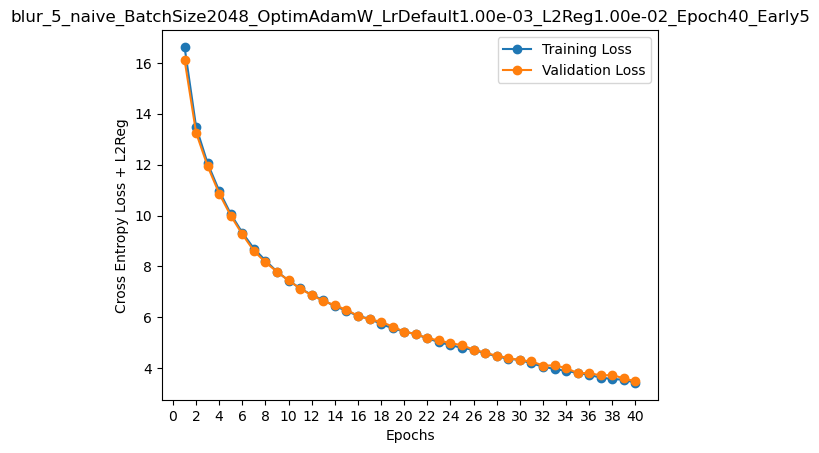

In [22]:
# Plot Loss over epochs

plt.figure()
plt.plot(np.arange(1, num_epochs + 1),
         [np.mean(x) for x in np.array_split(naive_training_losses,
                                             num_training_epochs)],
         "o-", label="Training Loss")
plt.plot(np.arange(1, num_epochs + 1),
         [np.mean(x) for x in np.array_split(naive_validation_losses,
                                             num_training_epochs)],
         "o-", label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss + L2Reg")
plt.xticks(np.arange(0, num_epochs+1, 2)) 
plt.legend()
plt.title(target + "_" + nn_type + "_BatchSize" + str(batch_size) + 
          "_Optim" + optim_type + "_Lr" + lr_type + f"{training_lr:.2e}" + 
          "_L2Reg" + f"{lamda_2:.2e}" + "_Epoch" + str(training_num_epoch) + "_Early5")
plt.show()

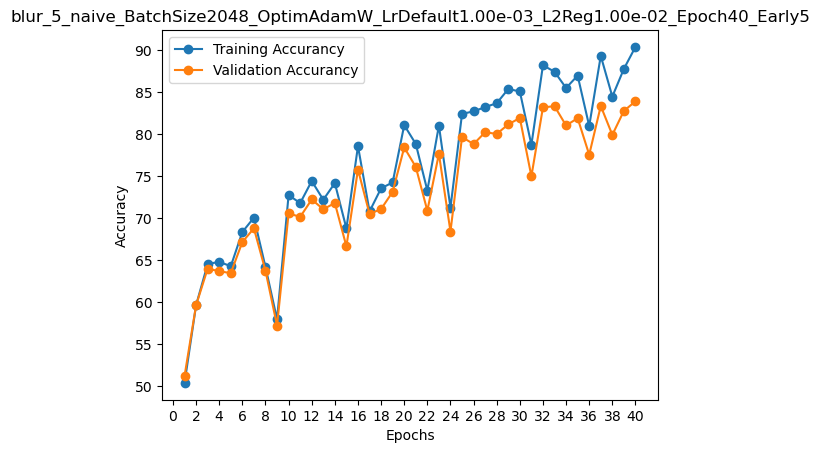

In [23]:
# Plot accuracy over epochs

plt.figure()
plt.plot(np.arange(1, num_epochs + 1),
         naive_training_accs,
         "o-", label="Training Accurancy")
plt.plot(np.arange(1, num_epochs + 1),
         naive_validation_accs,
         "o-", label="Validation Accurancy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0, num_epochs+1, 2)) 
plt.legend()
plt.title(target + "_" + nn_type + "_BatchSize" + str(batch_size) + 
          "_Optim" + optim_type + "_Lr" + lr_type + f"{training_lr:.2e}" + 
          "_L2Reg" + f"{lamda_2:.2e}" + "_Epoch" + str(training_num_epoch) + "_Early5")
plt.show()

In [24]:
# Save network weights
out_file = f"{out_path}/{target}_{nn_type}_BatchSize{batch_size}_Optim{optim_type}_Lr{lr_type}{training_lr:.2e}_L2Reg_{lamda_2:.2e}_Epoch{training_num_epoch}_Early{patience}"

torch.save(net.state_dict(), out_file)

In [26]:
import csv

outfile = f"{out_path}/loss_function_training_{target}_{nn_type}_BatchSize{batch_size}_Optim{optim_type}_Lr{lr_type}{training_lr:.2e}_L2Reg_{lamda_2:.2e}_Epoch{training_num_epoch}_Early{patience}"
with open(outfile, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Loss"])
    for idx, loss_val in enumerate([np.mean(x) for x in np.array_split(naive_training_losses,
                                             num_training_epochs)]):
        if hasattr(loss_val, "item"):
            loss_val = loss_val
        writer.writerow([idx, loss_val])

In [27]:
outfile = f"{out_path}/loss_function_validation_{target}_{nn_type}_BatchSize{batch_size}_Optim{optim_type}_Lr{lr_type}{training_lr:.2e}_L2Reg_{lamda_2:.2e}_Epoch{training_num_epoch}_Early{patience}"
with open(outfile, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Loss"])
    for idx, loss_val in enumerate([np.mean(x) for x in np.array_split(naive_validation_losses,
                                             num_training_epochs)]):
        if hasattr(loss_val, "item"):
            loss_val = loss_val
        writer.writerow([idx, loss_val])

In [29]:
outfile = f"{out_path}/accuracy_training_{target}_{nn_type}_BatchSize{batch_size}_Optim{optim_type}_Lr{lr_type}{training_lr:.2e}_L2Reg_{lamda_2:.2e}_Epoch{training_num_epoch}_Early{patience}"
with open(outfile, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Accuracy"])
    for idx, acc_val in enumerate(naive_training_accs):
        if hasattr(acc_val, "item"):
            acc_val = acc_val
        writer.writerow([idx, acc_val])

In [30]:
utfile = f"{out_path}/accuracy_validation_{target}_{nn_type}_BatchSize{batch_size}_Optim{optim_type}_Lr{lr_type}{training_lr:.2e}_L2Reg_{lamda_2:.2e}_Epoch{training_num_epoch}_Early{patience}"
with open(outfile, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Epoch", "Accuracy"])
    for idx, acc_val in enumerate(naive_validation_accs):
        if hasattr(acc_val, "item"):
            acc_val = acc_val
        writer.writerow([idx, acc_val])

  0%|          | 0/141 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the 17953 clear training samples before training: 50.00
Accuracy on the 2494 clear testing samples before training: 50.00


  0%|          | 0/141 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the 17953 clear training samples after training: 74.84
Accuracy on the 2494 clear testing samples after training: 75.30


  0%|          | 0/141 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the 17953 blurry training samples after training: 77.16
Accuracy on the 2494 blurry testing samples after training: 77.35


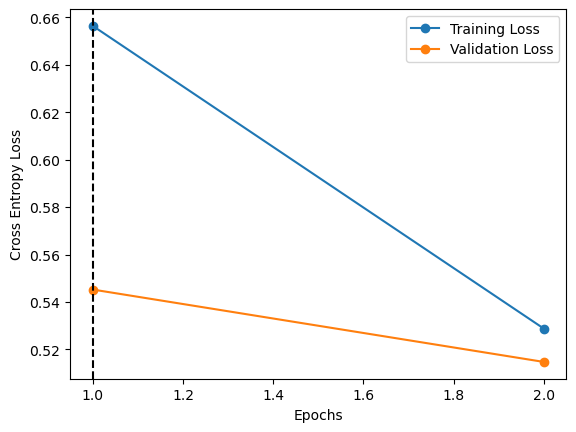

In [13]:
# Define network, loss function and optimizer
net = AlexNet(num_classes=2,downscale=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-4)
net.to(DEVICE)

# Evaluate before pretraining
evaluate(net, device=DEVICE, title="before training")

# Define number of epochs
num_pretraining_epochs = 1
num_training_epochs = 1
num_epochs = num_pretraining_epochs + num_training_epochs

# Save network weights
torch.save(net.state_dict(), "expert_before_training")

# Pretraining loop
training_losses, validation_losses = train(num_pretraining_epochs,
                                           clear_train_batches,
                                           clear_val_batches,
                                           device=DEVICE)

# Evaluate after pretraining
evaluate(net, device=DEVICE, title="after pretraining")

# Save network weights
torch.save(net.state_dict(), "expert_after_pretraining")

# Training loop
experienced_training_losses, experienced_validation_losses = train(num_training_epochs,
                                                                   noisy_train_batches,
                                                                   noisy_val_batches,
                                                                   training_losses=training_losses,
                                                                   validation_losses=validation_losses,
                                                                   device=DEVICE)

# Save network weights
torch.save(net.state_dict(), "expert_after_training")

# Evaluate after training
evaluate(net, device=DEVICE, title="after training")

# Plot Loss over epochs
plt.figure()
plt.plot(np.arange(1, num_epochs + 1),
         [np.mean(x) for x in np.array_split(experienced_training_losses,
                                             num_epochs)],
         "o-", label="Training Loss")
plt.plot(np.arange(1, num_epochs + 1),
         [np.mean(x) for x in np.array_split(experienced_validation_losses,
                                             num_epochs)],
         "o-", label="Validation Loss")
plt.axvline(num_pretraining_epochs, linestyle='dashed', color='k')
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.show()

In [14]:
# @title Helper Function to plot the 16 filters of the first layer
def plot_filter(net, title=""):
  layer = 0
  with torch.no_grad():
    params = list(net.parameters())
    fig, axs = plt.subplots(4, 4, figsize=(4, 4))
    filters = []
    for filter_index in range(min(16, params[layer].shape[0])):
      row_index = filter_index // 4
      col_index = filter_index % 4

      filter = params[layer][filter_index, :, :, :]
      filter_image = filter.permute((1, 2, 0))
      scale = np.abs(filter_image).max()
      scaled_image = filter_image / (2 * scale) + 0.5
      filters.append(scaled_image)
      axs[row_index, col_index].imshow(scaled_image)
      axs[row_index, col_index].axis('off')
    plt.suptitle(title)
    plt.show()

/glade/derecho/scratch/huangkai/tmp/ipykernel_52320/2162176671.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.abs(filter_image).max()


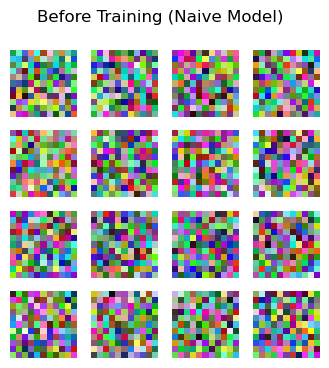

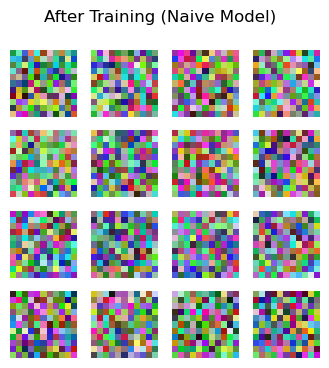

In [15]:
net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('naive_before_training'))
plot_filter(net, "Before Training (Naive Model)")

net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('naive_after_training'))
plot_filter(net, "After Training (Naive Model)")

/glade/derecho/scratch/huangkai/tmp/ipykernel_52320/2162176671.py:14: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale = np.abs(filter_image).max()


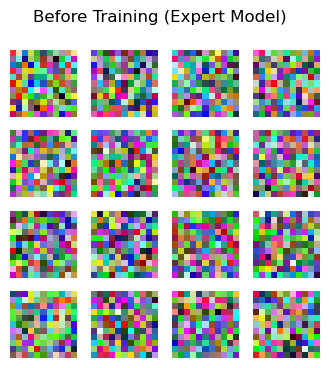

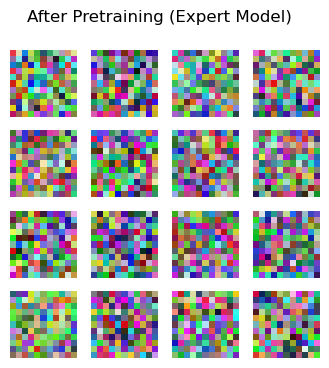

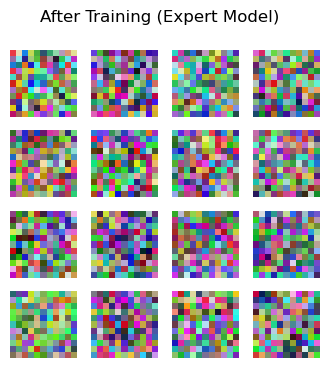

In [16]:
net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('expert_before_training'))
plot_filter(net, "Before Training (Expert Model)")

net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('expert_after_pretraining'))
plot_filter(net, "After Pretraining (Expert Model)")

net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('expert_after_training'))
plot_filter(net, "After Training (Expert Model)")

In [17]:
# choose intermidiate layers from which to get the output
return_layers = {
    # "<name of layer in the AlexNet Class>" : "<key for the layer output in the returned dictionary>"
      'v1': 'v1',
      'v2': 'v2',
      'v4': 'v4',
  }

In [18]:
# @title Helper functions to get and plot intermediate layer output

def plot_intermediate_layers(image, net, return_layers=return_layers):
  # Get output for the image from the intermediate layers
  intermediate_output = LayerGetter(net, return_layers=return_layers)(image)
  fig = plt.figure(figsize=(12, 3))
  ax=fig.add_subplot(141)
  ax.imshow(image.squeeze(0).permute(1, 2, 0))
  plt.axis('off')
  plt.title('Original Image')
  ax=fig.add_subplot(142)
  ax.imshow(intermediate_output[0]['v1'].detach().cpu().squeeze(0).mean(axis=0))
  plt.axis('off')
  plt.title('V1 layer (Average)')
  ax=fig.add_subplot(143)
  ax.imshow(intermediate_output[0]['v2'].detach().cpu().squeeze(0).mean(axis=0))
  plt.axis('off')
  plt.title('V2 layer (Average)')
  ax=fig.add_subplot(144)
  ax.imshow(intermediate_output[0]['v4'].detach().cpu().squeeze(0).mean(axis=0))
  plt.axis('off')
  plt.title('V4 layer (Average)')
  plt.show()

Naive Model
Before Training


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3793819..1.0000005].


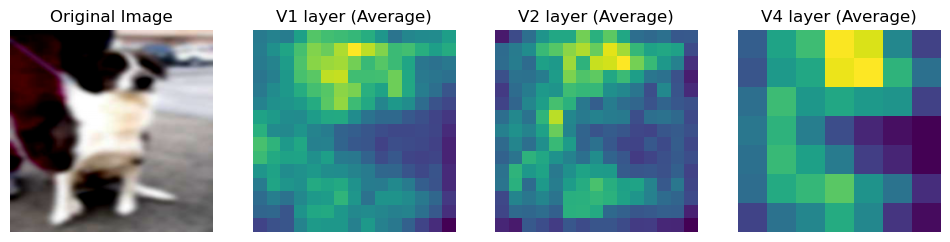

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271478..0.97307384].


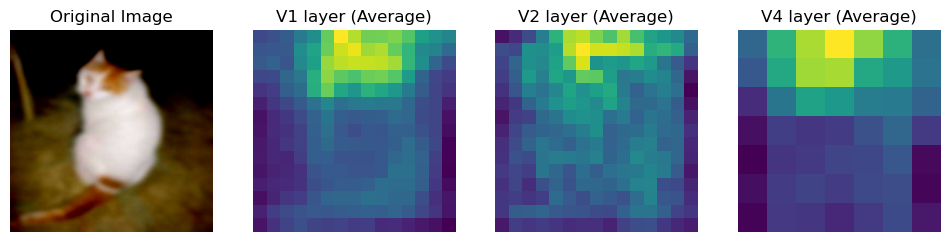

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3793819..1.0000005].


After Training


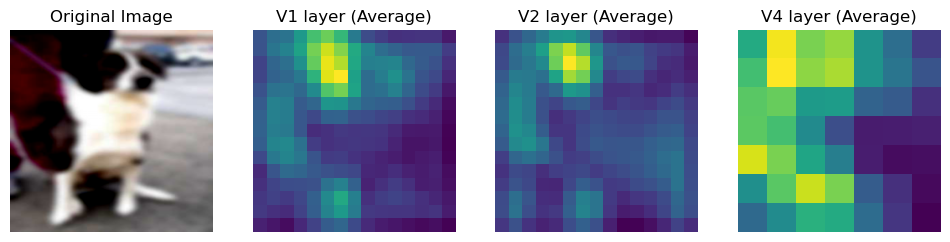

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271478..0.97307384].


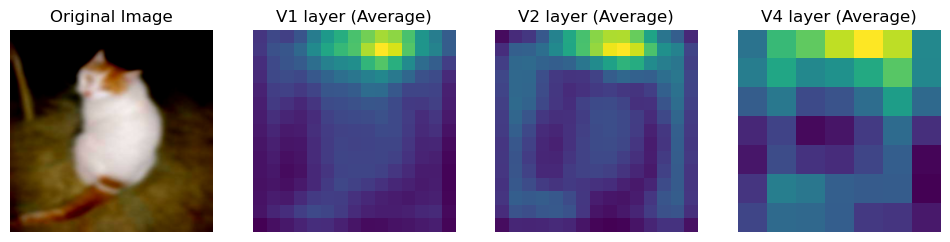

In [19]:
print("Naive Model\n=============")
print("Before Training")
net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('naive_before_training'))
plot_intermediate_layers(noisy_dog_image, net)
plot_intermediate_layers(noisy_cat_image, net)

print("After Training")
net = AlexNet(num_classes=2, downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('naive_after_training'))
plot_intermediate_layers(noisy_dog_image, net)
plot_intermediate_layers(noisy_cat_image, net)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3793819..1.0000005].


Expert Model
Before Training


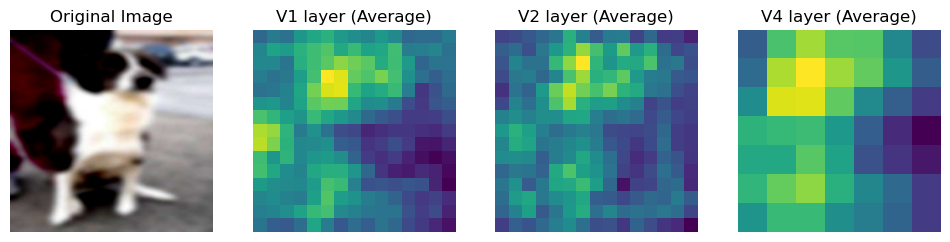

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271478..0.97307384].


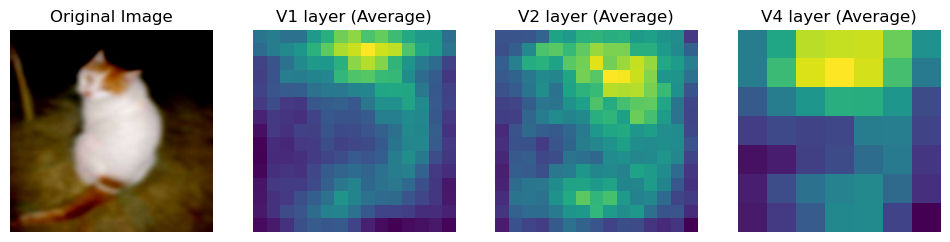

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3793819..1.0000005].


After Pretraining


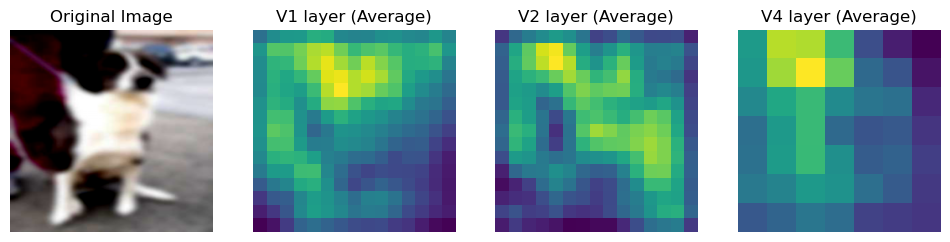

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271478..0.97307384].


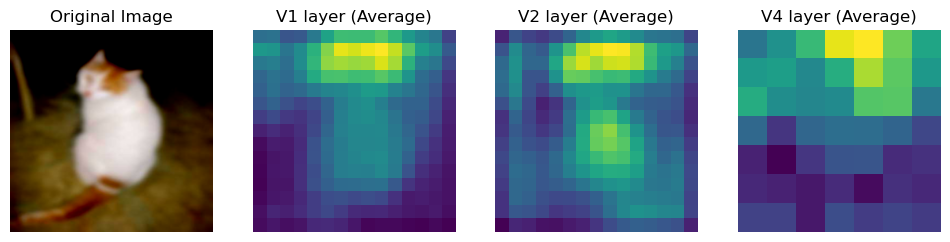

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3793819..1.0000005].


After Training


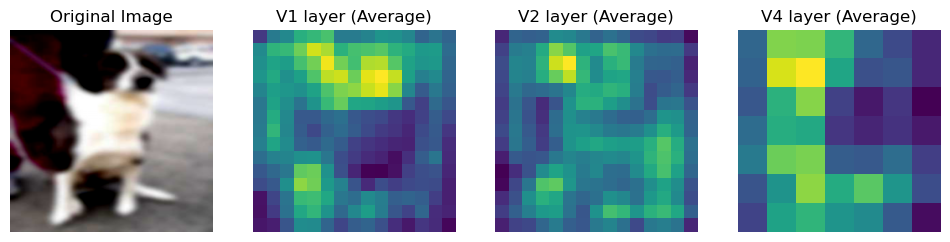

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9271478..0.97307384].


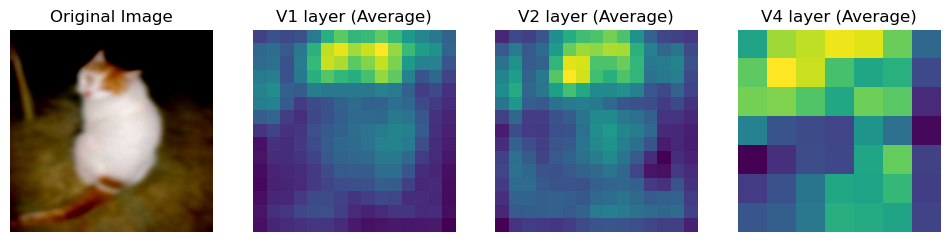

In [20]:
print("Expert Model\n=============")
print("Before Training")
net = AlexNet(num_classes=2,downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('expert_before_training'))
plot_intermediate_layers(noisy_dog_image,net)
plot_intermediate_layers(noisy_cat_image,net)

print("After Pretraining")
net = AlexNet(num_classes=2,downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('expert_after_pretraining'))
plot_intermediate_layers(noisy_dog_image,net)
plot_intermediate_layers(noisy_cat_image,net)

print("After Training")
net = AlexNet(num_classes=2,downscale=2)
# Load and assign previous state
net.load_state_dict(torch.load('expert_after_training'))
plot_intermediate_layers(noisy_dog_image,net)
plot_intermediate_layers(noisy_cat_image,net)

In [ ]:
# @markdown If you wish to generate cat and dog images with other degrees of blur or different type of noise
# @markdown refer to this cell which contains the code for dataset cleaning and filtering the original dataset.
# @markdown Feel free to uncomment and change the code to generate other variations of the dataset.

# @markdown *Note: The dataset generation process can take a while to run.*


# # Download the Data
# if "cats-and-dogs.zip" not in os.listdir():
#   !wget --no-check-certificate \
#     "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip" \
#     -O "cats-and-dogs.zip"

# local_zip = 'cats-and-dogs.zip'
# zip_ref   = zipfile.ZipFile(local_zip, 'r')
# zip_ref.extractall()
# zip_ref.close()

# cat_folder = "PetImages/Cat/"
# dog_folder = "PetImages/Dog/"

# def check_file(file):
#   try:
#     im = Image.open(file).convert('RGB')
#     #im = im.filter(ImageFilter.BLUR)
#     return True
#   except:
#     return False

# cat_files = list(filter(check_file, [cat_folder+i for i in os.listdir(cat_folder)]))
# dog_files = list(filter(check_file, [dog_folder+i for i in os.listdir(dog_folder)]))
# np.random.shuffle(cat_files)
# np.random.shuffle(dog_files)

# # Train test split
# test_ratio = 0.1
# # assert len(cat_files) == len(dog_files)
# N = min(len(cat_files),len(dog_files))

# training_length = int((1-test_ratio)*N)
# train_indices = np.arange(training_length)
# test_indices = np.arange(training_length,N)

# # Create data directory
# try:
#   os.mkdir("dataset")
#   os.mkdir("dataset/train/")
#   os.mkdir("dataset/test/")
#   os.mkdir("dataset/train/cat/")
#   os.mkdir("dataset/train/dog/")
#   os.mkdir("dataset/test/cat/")
#   os.mkdir("dataset/test/dog/")
#   os.mkdir("dataset_blur_5")
#   os.mkdir("dataset_blur_5/train/")
#   os.mkdir("dataset_blur_5/test/")
#   os.mkdir("dataset_blur_5/train/cat/")
#   os.mkdir("dataset_blur_5/train/dog/")
#   os.mkdir("dataset_blur_5/test/cat/")
#   os.mkdir("dataset_blur_5/test/dog/")
#   os.mkdir("dataset_blur_2")
#   os.mkdir("dataset_blur_2/train/")
#   os.mkdir("dataset_blur_2/test/")
#   os.mkdir("dataset_blur_2/train/cat/")
#   os.mkdir("dataset_blur_2/train/dog/")
#   os.mkdir("dataset_blur_2/test/cat/")
#   os.mkdir("dataset_blur_2/test/dog/")
# except:
#   pass

# for i in tqdm.tqdm(range(training_length)):
#   target = f"dataset/train/cat/{i+1}.jpg"
#   copyfile(cat_files[i],target)
#   target = f"dataset/train/dog/{i+1}.jpg"
#   copyfile(dog_files[i],target)
#   target = f"dataset_blur_2/train/cat/{i+1}.jpg"
#   im = Image.open(cat_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 2))
#   im.save(target)
#   target = f"dataset_blur_2/train/dog/{i+1}.jpg"
#   im = Image.open(dog_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 2))
#   im.save(target)
#   target = f"dataset_blur_5/train/cat/{i+1}.jpg"
#   im = Image.open(cat_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 5))
#   im.save(target)
#   target = f"dataset_blur_5/train/dog/{i+1}.jpg"
#   im = Image.open(dog_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 5))
#   im.save(target)

# for i in tqdm.tqdm(range(training_length,N)):
#   target = f"dataset/test/cat/{int(i-training_length+1)}.jpg"
#   copyfile(cat_files[i],target)
#   target = f"dataset/test/dog/{int(i-training_length+1)}.jpg"
#   copyfile(dog_files[i],target)
#   target = f"dataset_blur_2/test/cat/{int(i-training_length+1)}.jpg"
#   im = Image.open(cat_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 2))
#   im.save(target)
#   target = f"dataset_blur_2/test/dog/{int(i-training_length+1)}.jpg"
#   im = Image.open(dog_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 2))
#   im.save(target)
#   target = f"dataset_blur_5/test/cat/{int(i-training_length+1)}.jpg"
#   im = Image.open(cat_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 5))
#   im.save(target)
#   target = f"dataset_blur_5/test/dog/{int(i-training_length+1)}.jpg"
#   im = Image.open(dog_files[i]).convert('RGB')
#   im = im.filter(ImageFilter.GaussianBlur(radius = 5))
#   im.save(target)

# rmtree("PetImages")

# def zipdir(path, ziph):
#     # ziph is zipfile handle
#     for root, dirs, files in os.walk(path):
#         for file in files:
#             ziph.write(os.path.join(root, file),
#                        os.path.relpath(os.path.join(root, file),
#                                        os.path.join(path, '..')))

# zipf = zipfile.ZipFile('catvdog_clear.zip', 'w', zipfile.ZIP_DEFLATED)
# zipdir('dataset/', zipf)
# zipf.close()
# zipf = zipfile.ZipFile('catvdog_blur_2.zip', 'w', zipfile.ZIP_DEFLATED)
# zipdir('dataset_blur_2/', zipf)
# zipf.close()
# zipf = zipfile.ZipFile('catvdog_blur_5.zip', 'w', zipfile.ZIP_DEFLATED)
# zipdir('dataset_blur_5/', zipf)
# zipf.close()